# Block 3.1: Putting all together

Here we will combine the different architectures we've gone through to see if we can further increase the anomaly detection accuracy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"✅ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully
TensorFlow version: 2.20.0


### Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

#testing
import h5py

#adapt name
path = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2018 Data 60min.hdf5'  
f = h5py.File(path, 'r')

#Top‑level groups (e.g. 'NOPV', 'WITHPV', 'MISCSUBSTATION')
print(list(f.keys()))

g = f['NO_PV']                    # example - changed from NOPV to NO_PV
print(list(g.keys()))            # e.g. ['SFH3', 'SFH4', ...]

sfh3 = g['SFH3']
print(list(sfh3.keys()))         # e.g. ['HOUSEHOLD', 'HEATPUMP']

household = sfh3['HOUSEHOLD']
print(list(household.keys()))    # column names, e.g. ['index', 'P_TOT', 'Q_TOT', 'U_1', ...]
nopv = f['NO_PV']
sfh3 = nopv['SFH3']
household = sfh3['HOUSEHOLD']

timestamps = household['table']['index'][:]          # UNIX seconds
p_active   = household['table']['P_TOT'][:]          # W, active power [file:68]

def load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT'):
    grp = f[top][house][meter]
    return grp['table']['index'][:], grp['table'][column][:]

print(p_active)
inspect = load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT')
print(inspect)

ModuleNotFoundError: No module named 'google.colab'

### Local Data

In [3]:
import h5py
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Load real data from HDF5
def load_wpuq_household(filepath, house='SFH3', top='NO_PV', meter='HOUSEHOLD'):
    """Load household or heat pump power consumption from WPuQ dataset"""
    with h5py.File(filepath, 'r') as f:
        grp = f[top][house][meter]['table']

        timestamps_unix = grp['index'][:]        # UNIX seconds
        p_active = grp['P_TOT'][:]               # Active power in watts [file:68]
        q_reactive = grp['Q_TOT'][:]             # Reactive power (optional)

    # Convert UNIX timestamps to datetime
    timestamps = pd.to_datetime(timestamps_unix, unit='s')

    # Build DataFrame (similar structure to your dummy data)
    data = pd.DataFrame({
        'timestamp': timestamps,
        'consumption': p_active,              # Your main metric (W)
        'reactive_power': q_reactive,
        'hour': timestamps.hour,
        'day_of_week': timestamps.dayofweek,
        'month': timestamps.month,
        'is_weekend': (timestamps.dayofweek >= 5).astype(int)
    })

    data.set_index('timestamp', inplace=True)
    return data

# 2. Load and inspect
# filepath = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2019 Data 60min.hdf5'
filepath18 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Data 60min.hdf5'
data_2018 = load_wpuq_household(filepath18, house='SFH3', meter='HOUSEHOLD')
filepath19 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Data 60min.hdf5'
data_2019 = load_wpuq_household(filepath19, house='SFH3', meter='HOUSEHOLD')

# 3. Merge data
# 2018 data has Nan's between Jan and April
data_2018 = data_2018[data_2018.index.month >= 6]
data = pd.concat([data_2018, data_2019], axis=0)


print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head(n=15))
print(f"\nConsumption statistics:")
print(data['consumption'].describe())

def load_weather(filepath):
    """Load ambient temperature from weather data file"""
    with h5py.File(filepath, 'r') as f:

        table = f['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']
        print(f"Dataset shape: {table.shape}")
        print(f"Available columns (fields): {table.dtype.names}")
        # 2. Load Index

        ts = table['index'][:]
        print(ts)
        temps = table['TEMPERATURE:TOTAL'][:] 

    timestamps = pd.to_datetime(ts, unit='ns')
    temps_df = pd.DataFrame({
        'timestamp':timestamps, 
        'month': timestamps.month,
        'temperature': temps
    })
    temps_df.set_index('timestamp', inplace=True)
    
    # Resample to hourly (H) to match consumption data
    return temps_df.resample('H').mean()

weather_2018 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Weather Data.hdf5')
weather_2019 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Weather Data.hdf5')
weather_2018 = weather_2018[weather_2018.index.month >= 6]
weather_data = pd.concat([weather_2018, weather_2019], axis=0)

print(weather_2019.head())
# You only need the 'temperature' column from the weather data
data = data.join(weather_data[['temperature']], how='left').interpolate()  # Fill gaps
print(data.head())

Dataset shape: (13896, 6)
Date range: 2018-06-01 00:00:00 to 2019-12-31 23:00:00

First 5 rows:
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1            4      6   
2018-06-01 02:00:00    87.512389       -9.645250     2            4      6   
2018-06-01 03:00:00   184.230084       72.585944     3            4      6   
2018-06-01 04:00:00   118.397889       35.135694     4            4      6   
2018-06-01 05:00:00    67.159528      -23.663667     5            4      6   
2018-06-01 06:00:00   134.485889       58.459333     6            4      6   
2018-06-01 07:00:00   418.422585       48.184833     7            4      6   
2018-06-01 08:00:00   323.888027       24.571528     8            4      6   
2018-06-01 09:00:00   715.743057      -21.3035

# Prepare Data

In [5]:
def create_windows(data, window_size=24):
    """
    Create rolling windows of consumption data.

    Parameters:
    -----------
    data : array
        Time series data (1D)
    window_size : int
        Size of rolling window (default: 24 hours)

    Returns:
    --------
    windows : numpy array (samples, window_size)
        Rolling windows
    """
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# Create 24-hour rolling windows
window_size = 24

# Notice the log scaling
consumption_values = np.log(data['consumption'].values)

X_windows = create_windows(consumption_values, window_size=window_size)

print(f"Rolling windows created:")
print(f"  Shape: {X_windows.shape} (samples, hours)")
print(f"  Each sample = {window_size} consecutive hours of consumption")
print(f"\nExample window (first 24 hours):")
print(X_windows[0])

# Chronological split
split_idx = int(len(X_windows) * 0.8)

X_train_normal = X_windows[:split_idx]
X_test = X_windows[split_idx:]

print(f"Train set (normal data): {X_train_normal.shape[0]:,} samples")
print(f"Test set:                 {X_test.shape[0]:,} samples")
print(f"\nTrain set is 100% normal consumption (by assumption)")
print(f"Test set may contain anomalies (we'll inject some later)")

# Normalize windows (important for neural networks)
scaler = MinMaxScaler()
X_train_normal = scaler.fit_transform(X_train_normal)
X_test = scaler.transform(X_test)

Rolling windows created:
  Shape: (13874, 24) (samples, hours)
  Each sample = 24 consecutive hours of consumption

Example window (first 24 hours):
[4.67808447 4.85348017 4.47178037 5.21618543 4.77405089 4.2070708
 4.90145928 6.03649189 5.78039786 6.57332124 4.92317513 4.79423332
 4.76652911 5.32740883 6.42974985 6.90135277 5.40852698 5.56227715
 5.32151835 5.23081609 4.66240108 5.09864702 4.58448096 4.74254329]
Train set (normal data): 11,099 samples
Test set:                 2,775 samples

Train set is 100% normal consumption (by assumption)
Test set may contain anomalies (we'll inject some later)


# LSTM AE

Reshaping data for LSTM...
X_train_lstm shape: (11099, 24, 1)
X_test_lstm shape:  (2775, 24, 1)

LSTM AUTOENCODER ARCHITECTURE


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 16)         │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,205 (59.39 KB)

 Trainable params: 15,205 (59.39 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Autoencoder...
Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1762 - mae: 0.1093 - val_loss: 0.0151 - val_mae: 0.0891
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0158 - mae: 0.0895 - val_loss: 0.0146 - val_mae: 0.0879
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0152 - mae: 0.0880 - val_loss: 0.0145 - val_mae: 0.0881
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0146 - mae: 0.0860 - val_loss: 0.0136 - val_mae: 0.0863
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0137 - mae: 0.0831 - val_loss: 0.0125 - val_mae: 0.0819
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0132 - mae: 0.0817 - val_loss: 0.0125 - val_mae: 0.0814
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0130 - mae: 0.0810 - val_loss: 0.0124 - val_mae: 0.0817
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0128 - mae: 0.0806 - val_loss: 0.0122 - val_mae: 0.0812
Epoch 9/50
635/635 ━━━━━━━

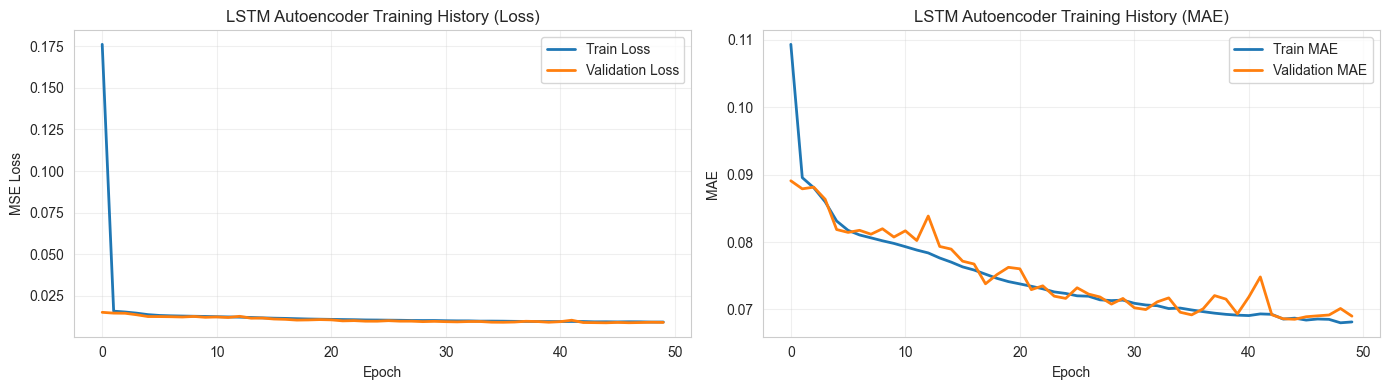


Final Training Loss:      0.009241
Final Validation Loss:    0.008983


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# =========================================================
# 1. RESHAPE DATA FOR LSTM (Time Series Format)
# =========================================================
# LSTM expects 3D input: (samples, timesteps, features)
# Your current data is 2D: (samples, 24)
# We reshape to: (samples, 24, 1) - treating each 24-hour window as a sequence

print("Reshaping data for LSTM...")
X_train_lstm = X_train_normal.reshape(-1, window_size, 1)
X_test_lstm = X_test.reshape(-1, window_size, 1)

print(f"X_train_lstm shape: {X_train_lstm.shape}")  # (samples, 24, 1)
print(f"X_test_lstm shape:  {X_test_lstm.shape}")   # (samples, 24, 1)

# =========================================================
# 2. BUILD LSTM AUTOENCODER
# =========================================================
input_shape = (window_size, 1)  # (24, 1)
latent_dim = 4

# --- ENCODER ---
encoder_input = Input(shape=input_shape, name='encoder_input')

# LSTM layers to compress the sequence
x = layers.LSTM(32, activation='relu', return_sequences=True, name='encoder_lstm_1')(encoder_input)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(16, activation='relu', return_sequences=False, name='encoder_lstm_2')(x)
x = layers.Dropout(0.2)(x)

# Dense layer to create latent representation
latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

# --- DECODER ---
# Repeat latent vector for each time step (24 times)
x = layers.RepeatVector(window_size, name='repeat_vector')(latent)

# LSTM layers to reconstruct the sequence
x = layers.LSTM(16, activation='relu', return_sequences=True, name='decoder_lstm_1')(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32, activation='relu', return_sequences=True, name='decoder_lstm_2')(x)
x = layers.Dropout(0.2)(x)

# Dense layer to reconstruct back to original dimension
decoder_output = layers.TimeDistributed(
    layers.Dense(1, activation='linear'), 
    name='decoder_output'
)(x)

# --- BUILD FULL AUTOENCODER ---
autoencoder_lstm = Model(inputs=encoder_input, outputs=decoder_output, name='LSTM_Autoencoder')

# --- BUILD SEPARATE ENCODER (FOR LATENT SPACE VISUALIZATION) ---
encoder_lstm = Model(inputs=encoder_input, outputs=latent, name='Encoder')

# Compile
autoencoder_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n" + "="*70)
print("LSTM AUTOENCODER ARCHITECTURE")
print("="*70)
autoencoder_lstm.summary()

# =========================================================
# 3. TRAIN LSTM AUTOENCODER
# =========================================================
print("\nTraining LSTM Autoencoder...")

history = autoencoder_lstm.fit(
    X_train_lstm, X_train_lstm,  # Input and target are the same (reconstruction task)
    epochs=50,
    batch_size=14,
    validation_split=0.2,
    verbose=1,
    shuffle=True
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('LSTM Autoencoder Training History (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('LSTM Autoencoder Training History (MAE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss:      {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss:    {history.history['val_loss'][-1]:.6f}")


Generating Latent Space Visualization...


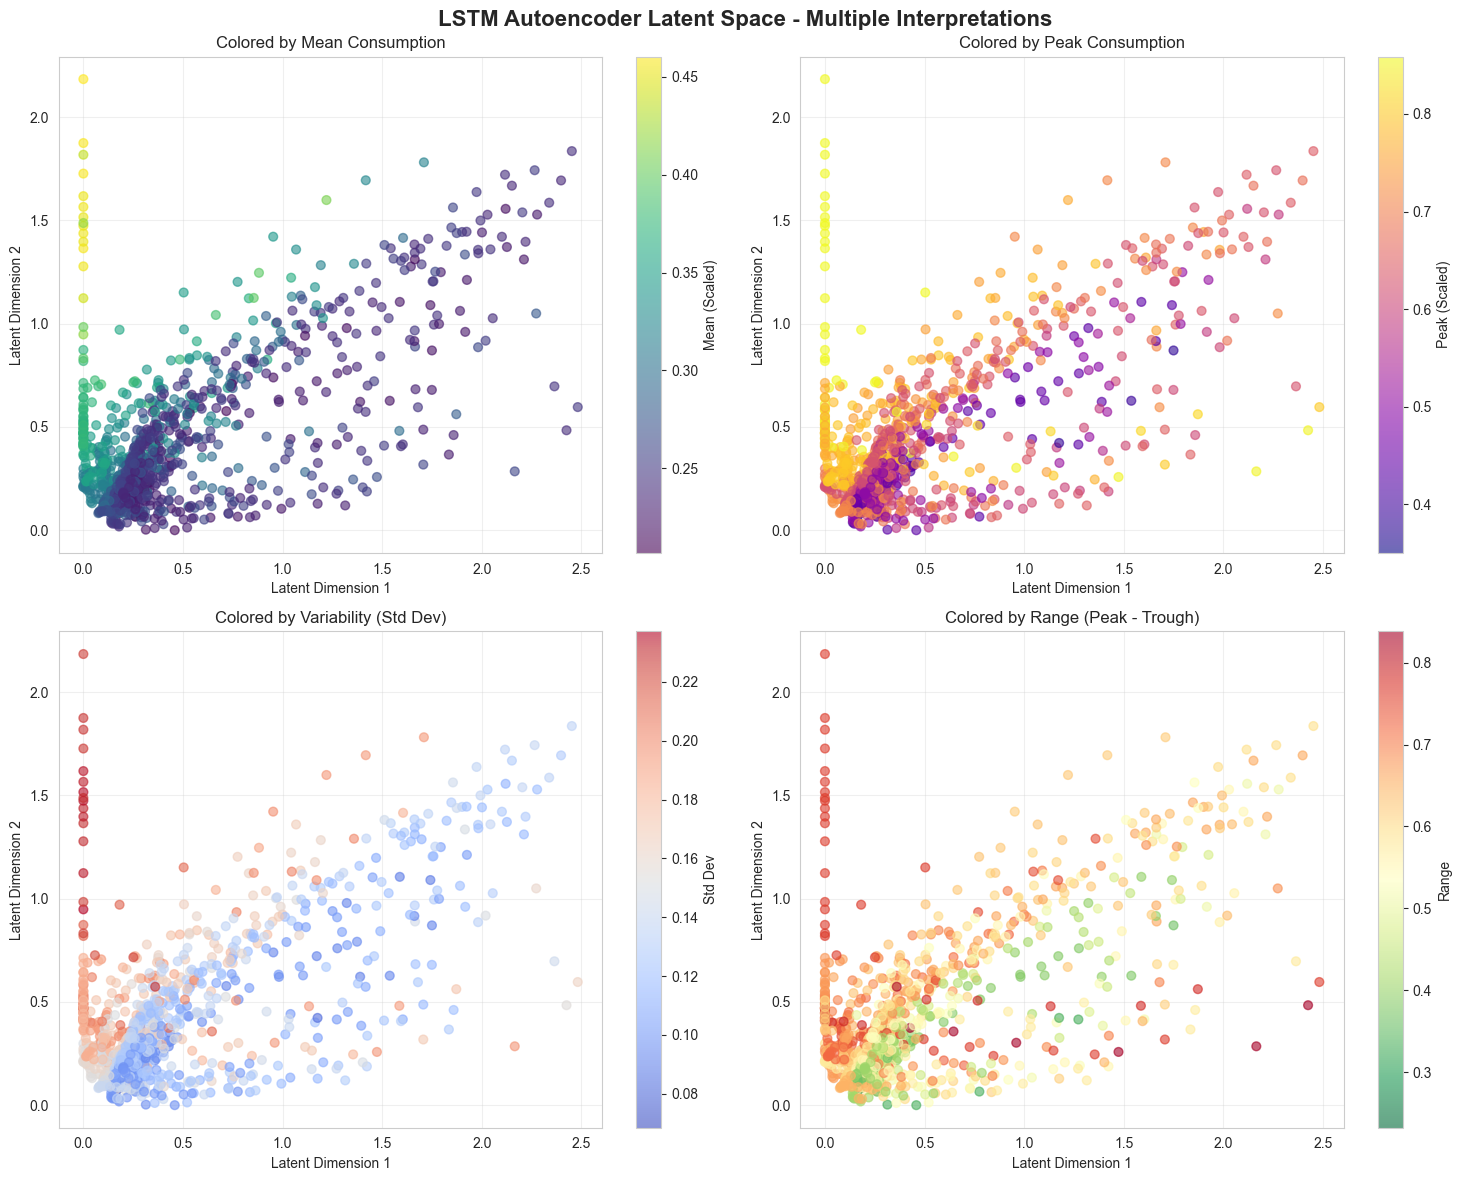

Complete!


In [8]:
# =========================================================
# 7. VISUALIZE LATENT SPACE (SAME AS BEFORE)
# =========================================================
print("\nGenerating Latent Space Visualization...")

latent_train = encoder_lstm.predict(X_train_lstm[:1000], verbose=0)

# Calculate metrics
window_means = np.mean(X_train_lstm[:1000], axis=1)
window_peaks = np.max(X_train_lstm[:1000], axis=1)
window_stds = np.std(X_train_lstm[:1000], axis=1)
window_ranges = np.max(X_train_lstm[:1000], axis=1) - np.min(X_train_lstm[:1000], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('LSTM Autoencoder Latent Space - Multiple Interpretations', fontsize=16, fontweight='bold')

# Plot A: Mean Consumption
ax = axes[0, 0]
scatter_a = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_means.reshape(-1), cmap='viridis', alpha=0.6, s=40)
ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title('Colored by Mean Consumption')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter_a, ax=ax, label='Mean (Scaled)')

# Plot B: Peak Consumption
ax = axes[0, 1]
scatter_b = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_peaks.reshape(-1), cmap='plasma', alpha=0.6, s=40)
ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title('Colored by Peak Consumption')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter_b, ax=ax, label='Peak (Scaled)')

# Plot C: Variability
ax = axes[1, 0]
scatter_c = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_stds.reshape(-1), cmap='coolwarm', alpha=0.6, s=40)
ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title('Colored by Variability (Std Dev)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter_c, ax=ax, label='Std Dev')

# Plot D: Range
ax = axes[1, 1]
scatter_d = ax.scatter(latent_train[:, 0], latent_train[:, 1],
                       c=window_ranges.reshape(-1), cmap='RdYlGn_r', alpha=0.6, s=40)
ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title('Colored by Range (Peak - Trough)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter_d, ax=ax, label='Range')

plt.tight_layout()
plt.show()

print("Complete!")

In [9]:
# =========================================================
# 4. EVALUATE ON TEST SET (WITHOUT FRAUD)
# =========================================================
print("\n" + "="*70)
print("TESTING ON NORMAL DATA")
print("="*70)

X_test_reconstructed = autoencoder_lstm.predict(X_test_lstm, verbose=0)

# Calculate reconstruction error for normal test data
residuals_normal = X_test_reconstructed - X_test_lstm
reconstruction_error = np.mean(np.power(np.maximum(residuals_normal, 0), 2), axis=(1, 2))

# Calculate threshold (95th percentile)
threshold_normal = np.percentile(reconstruction_error, 95)
# Detect anomalies
anomalies = reconstruction_error > threshold_normal
anomaly_indices = np.where(anomalies)[0]

print(f"\nNormal Test Data - Theft Score Statistics:")
print(f"  Mean:   {reconstruction_error.mean():.6f}")
print(f"  Median: {np.median(reconstruction_error):.6f}")
print(f"  Std:    {reconstruction_error.std():.6f}")
print(f"  Min:    {reconstruction_error.min():.6f}")
print(f"  Max:    {reconstruction_error.max():.6f}")
print(f"\nThreshold (95th percentile): {threshold_normal:.6f}")
print(f"\nAnomalies detected: {anomalies.sum()} / {len(reconstruction_error)} ({anomalies.sum()/len(reconstruction_error)*100:.1f}%)")
print(f"="*60)


TESTING ON NORMAL DATA

Normal Test Data - Theft Score Statistics:
  Mean:   0.002113
  Median: 0.001839
  Std:    0.001268
  Min:    0.000280
  Max:    0.011353

Threshold (95th percentile): 0.004596

Anomalies detected: 139 / 2775 (5.0%)


In [10]:
# =========================================================
# 5. CREATE SYNTHETIC FRAUD & EVALUATE
# =========================================================
print("\n" + "="*70)
print("CREATING SYNTHETIC FRAUD DATA")
print("="*70)

X_test_with_fraud = X_test_lstm.copy()

# Inject fraud: Drop to near-zero for 6 hours (energy theft)
np.random.seed(75)
fraud_rate = 0.05
n_fraud = int(len(X_test_lstm) * fraud_rate)
fraud_indices = np.random.choice(len(X_test_lstm), size=n_fraud, replace=False)

for idx in fraud_indices:
    start = np.random.randint(0, 18)  # Random start hour
    reduction_factor = np.random.uniform(0.2, 0.3)  # 70-80% reduction
    X_test_with_fraud[idx, start:start+6, :] = X_test_with_fraud[idx, start:start+6, :]*reduction_factor  

y_true = np.zeros(len(X_test_lstm), dtype=int)
y_true[fraud_indices] = 1

print(f"Synthetic fraud dataset created:")
print(f"  Total samples: {len(X_test_lstm)}")
print(f"  Fraud injected: {n_fraud} samples ({fraud_rate*100:.0f}%)")
print(f"  Normal: {len(X_test_lstm) - n_fraud} samples ({(1-fraud_rate)*100:.0f}%)")

# =========================================================
# 6. DETECT FRAUD USING LSTM AUTOENCODER
# =========================================================
print("\n" + "="*70)
print("FRAUD DETECTION WITH LSTM AUTOENCODER")
print("="*70)

X_fraud_reconstructed = autoencoder_lstm.predict(X_test_with_fraud, verbose=0)

# Calculate directional theft score (only penalize when Predicted > Actual)
residuals_fraud = X_fraud_reconstructed - X_test_with_fraud
residuals_positive = np.maximum(residuals_fraud, 0)
theft_score_fraud = np.mean(np.power(residuals_positive, 2), axis=(1, 2))
threshold_directional = np.percentile(theft_score_fraud, 95)

# Detect anomalies
fraud_detected = theft_score_fraud > threshold_directional

# Evaluate
precision = precision_score(y_true, fraud_detected)
recall = recall_score(y_true, fraud_detected)
f1 = f1_score(y_true, fraud_detected)
accuracy = accuracy_score(y_true, fraud_detected)

print(f"\nGround Truth:")
print(f"  Fraud cases: {y_true.sum()}")
print(f"  Normal cases: {len(y_true) - y_true.sum()}")

print(f"\nDetection Results:")
print(f"  Flagged as anomaly: {fraud_detected.sum()}")
print(f"  True positives (fraud caught): {np.sum((y_true == 1) & (fraud_detected == 1))}")
print(f"  False positives (normal flagged): {np.sum((y_true == 0) & (fraud_detected == 1))}")
print(f"  False negatives (fraud missed): {np.sum((y_true == 1) & (fraud_detected == 0))}")

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f} (of flagged cases, % truly fraud)")
print(f"  Recall:    {recall:.3f} (of fraud cases, % detected)")
print(f"  F1-Score:  {f1:.3f}")
print("="*70)

# =========================================================
# 4. Other Thresholds
# =========================================================
#print("\n" + "="*70)
#print("TESTING ON NORMAL DATA")
#print("="*70)

#X_test_reconstructed = autoencoder_lstm.predict(X_test_lstm, verbose=0)

# ============= OPTION 1: MAE (More Stable) =============
#residuals_normal = np.abs(X_test_reconstructed - X_test_lstm)
#theft_score_normal = np.mean(residuals_normal, axis=(1, 2))

# IMPORTANT: Use more conservative threshold with MAE
# Option A: Higher percentile
#threshold_mae = np.percentile(theft_score_normal, 99)  # Changed from 95 to 99

# Option B: IQR method (more robust - RECOMMENDED)
#q1 = np.percentile(theft_score_normal, 25)
#q3 = np.percentile(theft_score_normal, 75)
#iqr = q3 - q1
#threshold_iqr = q3 + 3.0 * iqr  # k=3 is conservative, k=1.5 is standard

#print(f"\nNormal Test Data - Theft Score Statistics (MAE):")
#print(f"  Mean:   {theft_score_normal.mean():.6f}")
#print(f"  Median: {np.median(theft_score_normal):.6f}")
#print(f"  Std:    {theft_score_normal.std():.6f}")
#print(f"  Min:    {theft_score_normal.min():.6f}")
#print(f"  Max:    {theft_score_normal.max():.6f}")
#print(f"  Q1:     {q1:.6f}")
#print(f"  Q3:     {q3:.6f}")
#print(f"  IQR:    {iqr:.6f}")
#print(f"\nThreshold (99th percentile): {threshold_mae:.6f}")
#print(f"Threshold (IQR, k=3.0):       {threshold_iqr:.6f}")




CREATING SYNTHETIC FRAUD DATA
Synthetic fraud dataset created:
  Total samples: 2775
  Fraud injected: 138 samples (5%)
  Normal: 2637 samples (95%)

FRAUD DETECTION WITH LSTM AUTOENCODER

Ground Truth:
  Fraud cases: 138
  Normal cases: 2637

Detection Results:
  Flagged as anomaly: 139
  True positives (fraud caught): 105
  False positives (normal flagged): 34
  False negatives (fraud missed): 33

Metrics:
  Accuracy:  0.976
  Precision: 0.755 (of flagged cases, % truly fraud)
  Recall:    0.761 (of fraud cases, % detected)
  F1-Score:  0.758



CONFUSION MATRIX

Confusion Matrix:
  True Negatives (TN):  2603
  False Positives (FP): 34
  False Negatives (FN): 33
  True Positives (TP):  105


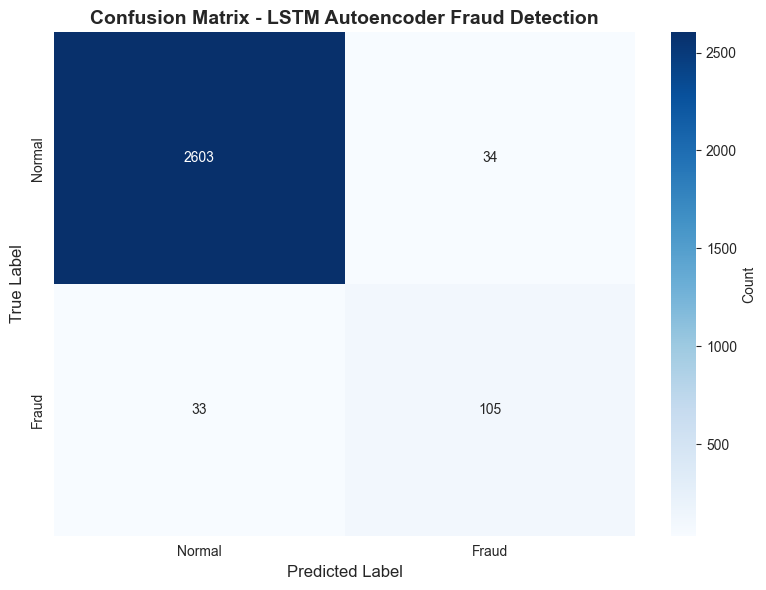


RECONSTRUCTION ERROR ANALYSIS


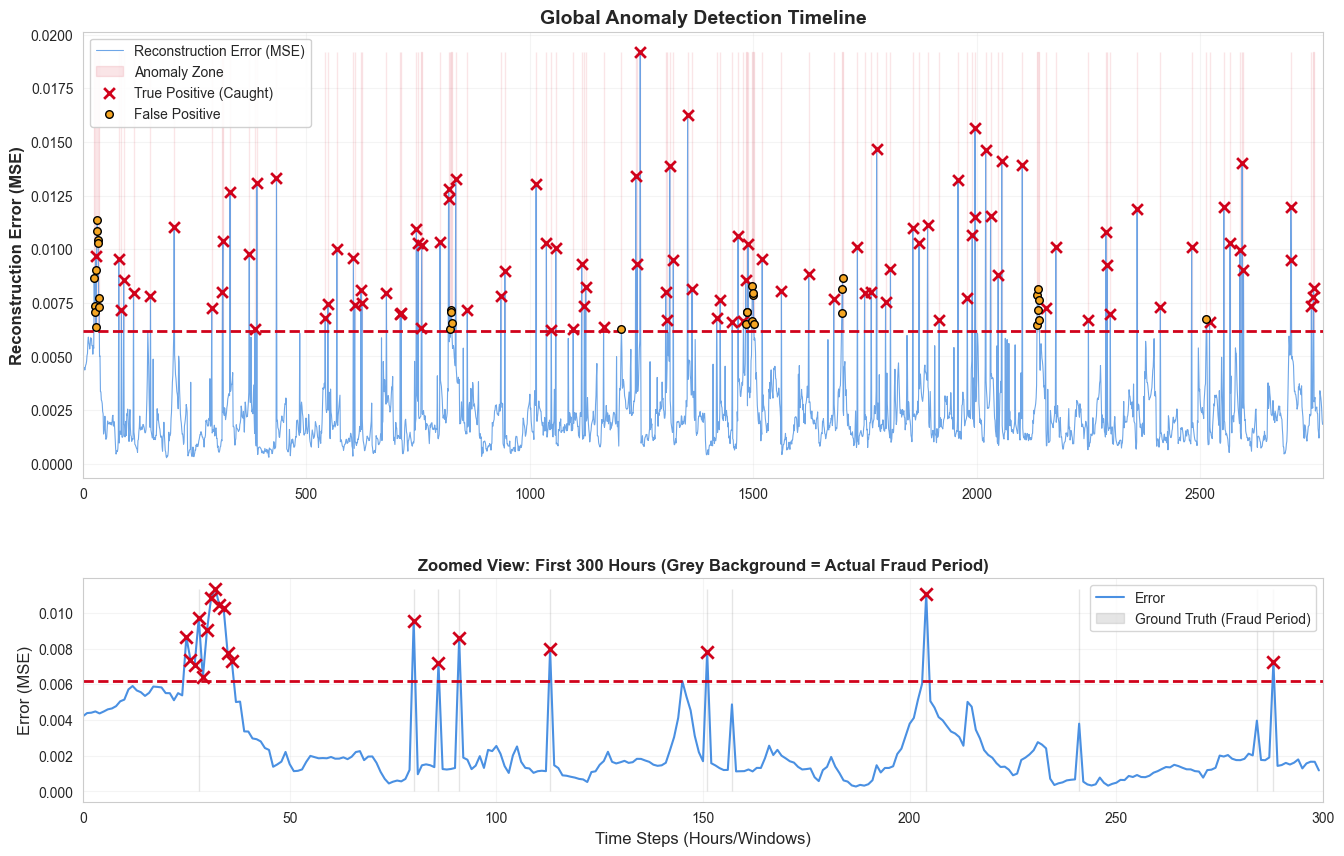

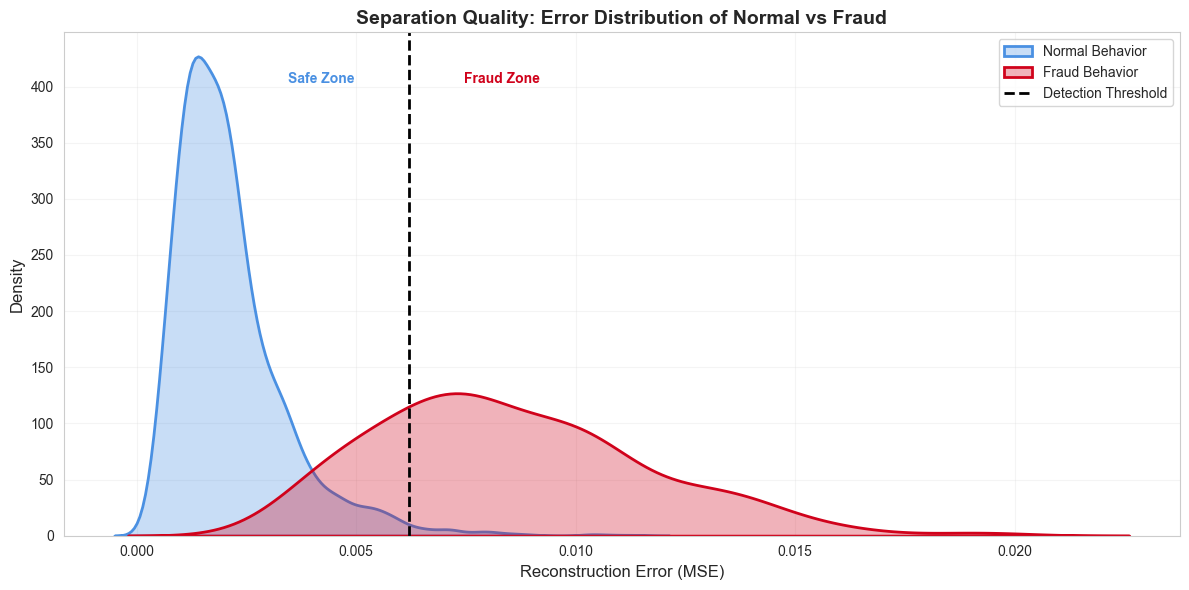

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, auc, roc_auc_score
)

# =========================================================
# 1. CONFUSION MATRIX
# =========================================================
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, fraud_detected)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix - LSTM Autoencoder Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================
# 2. PROFESSIONAL RECONSTRUCTION ERROR ANALYSIS
# =========================================================
print("\n" + "="*70)
print("RECONSTRUCTION ERROR ANALYSIS")
print("="*70)

# Create a figure with 2 subplots (Main Timeline + Zoomed View)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.3)

# --- SUBPLOT 1: FULL TIMELINE ---
ax1 = fig.add_subplot(gs[0])

# Plot the continuous error signal
ax1.plot(theft_score_fraud, linewidth=0.8, color='#4A90E2', alpha=0.8, label='Reconstruction Error (MSE)')

# Add a shaded "Danger Zone" above threshold
ax1.axhline(threshold_directional, color='#D0021B', linestyle='--', linewidth=2, zorder=3)
ax1.fill_between(range(len(theft_score_fraud)), threshold_directional, theft_score_fraud.max(), 
                 where=(theft_score_fraud > threshold_directional),
                 color='#D0021B', alpha=0.1, label='Anomaly Zone')

# Highlight True Positives (Caught Fraud) vs False Positives (False Alarm)
tp_indices = np.where((y_true == 1) & (fraud_detected == 1))[0]
fp_indices = np.where((y_true == 0) & (fraud_detected == 1))[0]

ax1.scatter(tp_indices, theft_score_fraud[tp_indices], 
            color='#D0021B', marker='x', s=60, linewidth=2, label='True Positive (Caught)', zorder=4)
ax1.scatter(fp_indices, theft_score_fraud[fp_indices], 
            color='#F5A623', marker='o', s=30, linewidth=1, edgecolors='black', label='False Positive', zorder=4)

ax1.set_ylabel('Reconstruction Error (MSE)', fontsize=12, fontweight='bold')
ax1.set_title('Global Anomaly Detection Timeline', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
ax1.grid(True, alpha=0.2)
ax1.set_xlim(0, len(theft_score_fraud))

# --- SUBPLOT 2: ZOOMED VIEW (First 300 Samples) ---
# This helps inspect the "shape" of anomalies
ax2 = fig.add_subplot(gs[1])
zoom_slice = slice(0, 300) 

ax2.plot(theft_score_fraud[zoom_slice], linewidth=1.5, color='#4A90E2', label='Error')
ax2.axhline(threshold_directional, color='#D0021B', linestyle='--', linewidth=2)

# Shade actual fraud regions in the background (Ground Truth)
fraud_regions = y_true[zoom_slice] == 1
ax2.fill_between(range(300), 0, theft_score_fraud[zoom_slice].max(), 
                 where=fraud_regions, color='gray', alpha=0.2, label='Ground Truth (Fraud Period)')

# Mark detections
ax2.scatter(np.where(fraud_detected[zoom_slice])[0], theft_score_fraud[zoom_slice][fraud_detected[zoom_slice]], 
            color='#D0021B', marker='x', s=80, linewidth=2, zorder=5)

ax2.set_xlabel('Time Steps (Hours/Windows)', fontsize=12)
ax2.set_ylabel('Error (MSE)', fontsize=12)
ax2.set_title('Zoomed View: First 300 Hours (Grey Background = Actual Fraud Period)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, 300)

plt.show()

# =========================================================
# 3. DISTRIBUTION DENSITY (KDE PLOT)
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Separate errors
normal_errors = theft_score_fraud[y_true == 0]
fraud_errors = theft_score_fraud[y_true == 1]

# Plot KDE (Kernel Density Estimate) for smoother visualization
sns.kdeplot(normal_errors, fill=True, color='#4A90E2', alpha=0.3, linewidth=2, label='Normal Behavior', ax=ax)
sns.kdeplot(fraud_errors, fill=True, color='#D0021B', alpha=0.3, linewidth=2, label='Fraud Behavior', ax=ax)

# Add Threshold Line
ax.axvline(threshold_directional, color='black', linestyle='--', linewidth=2, label='Detection Threshold')

# Add Annotations
ax.text(threshold_directional * 0.8, ax.get_ylim()[1]*0.9, 'Safe Zone', ha='right', color='#4A90E2', fontweight='bold')
ax.text(threshold_directional * 1.2, ax.get_ylim()[1]*0.9, 'Fraud Zone', ha='left', color='#D0021B', fontweight='bold')

ax.set_xlabel('Reconstruction Error (MSE)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Separation Quality: Error Distribution of Normal vs Fraud', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

